In [44]:
import pandas as pd

In [45]:
df=pd.read_csv('google.csv')

In [46]:
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [47]:
import matplotlib.pyplot as plt

In [48]:
df['Rating']=df['Rating'].astype(float)

In [49]:
df['Price']=df['Price'].str.removeprefix('$')
df['Price']=df['Price'].replace({'Everyone':None})
df['Price']=df['Price'].astype(float)

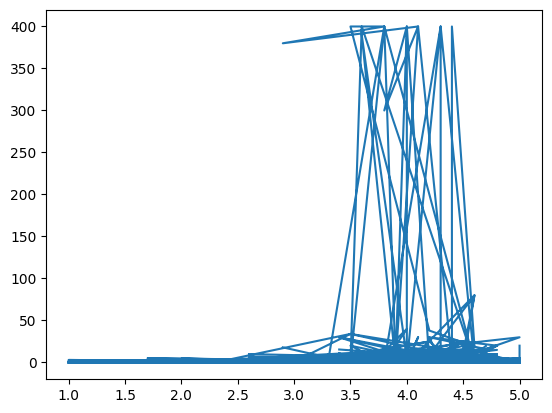

In [50]:
plt.plot(df['Rating'],df['Price'])

Text(0, 0.5, 'Price')

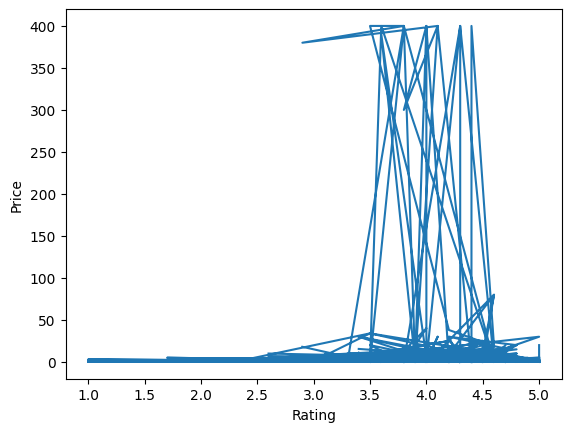

In [51]:
plt.plot(df['Rating'],df['Price'])
plt.xlabel("Rating")
plt.ylabel("Price")

In [52]:
import seaborn as sns

<Axes: xlabel='Rating', ylabel='Price'>

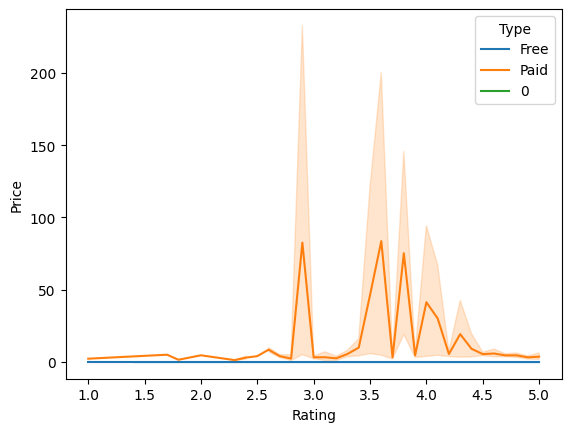

In [53]:
sns.lineplot(x='Rating',y='Price',data=df,hue='Type')

In [54]:
df['Last Updated']=df['Last Updated'].replace({'1.0.19':'January 1, 2018'})

In [55]:
df['Last Updated']=pd.to_datetime(df['Last Updated'])

In [56]:
df['Year']=df['Last Updated'].dt.year
df['Year']

0        2018
1        2018
2        2018
3        2018
4        2018
         ... 
10836    2017
10837    2018
10838    2017
10839    2015
10840    2018
Name: Year, Length: 10841, dtype: int32

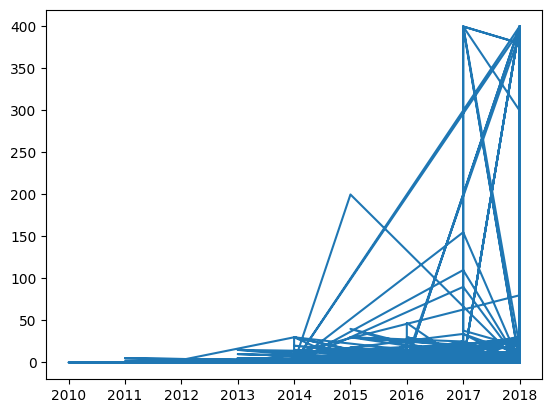

In [57]:
plt.plot(df['Year'],df['Price'])

<Axes: xlabel='Year', ylabel='Price'>

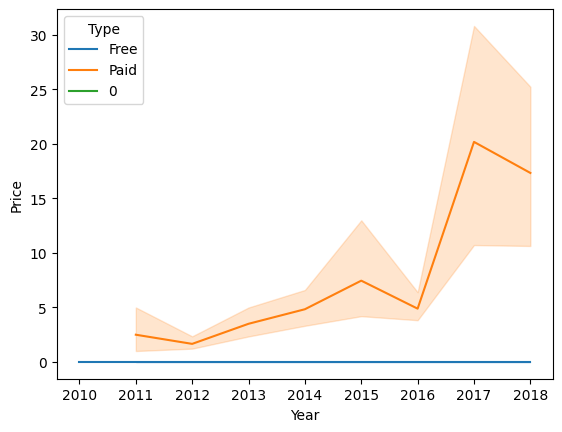

In [58]:
sns.lineplot(x='Year',y='Price',data=df,hue='Type')

<Axes: xlabel='Year', ylabel='Price'>

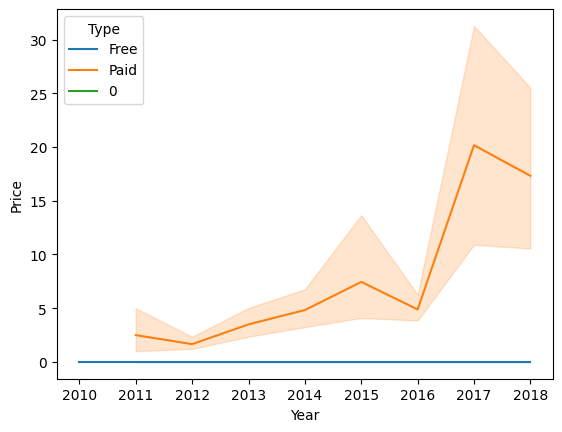

In [59]:
sns.lineplot(x=df['Year'],y=df['Price'],hue=df['Type'])

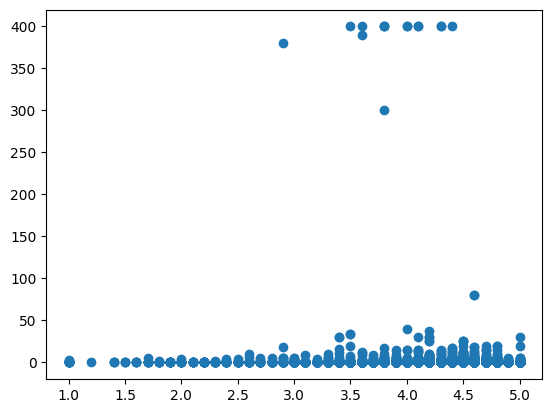

In [60]:
plt.scatter(df['Rating'],df['Price'])

<Axes: xlabel='Rating', ylabel='Price'>

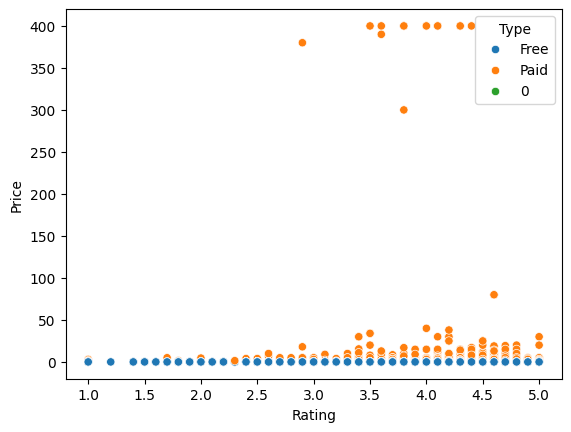

In [61]:
sns.scatterplot(x='Rating',y='Price',data=df,hue='Type')
#or we can do like this : sns.scatterplot(x=df['Rating'],y=df['Price],hue=df['Type'])

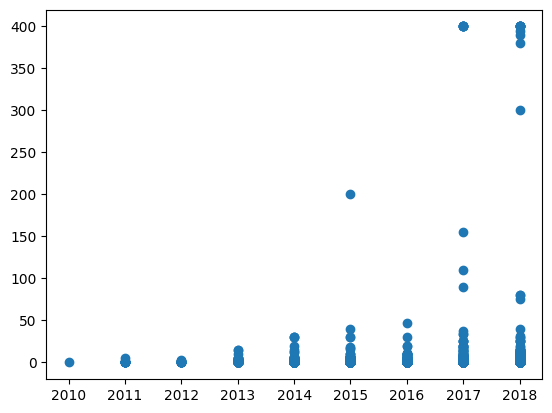

In [62]:
plt.scatter(df['Year'],df['Price'])

<Axes: xlabel='Year', ylabel='Price'>

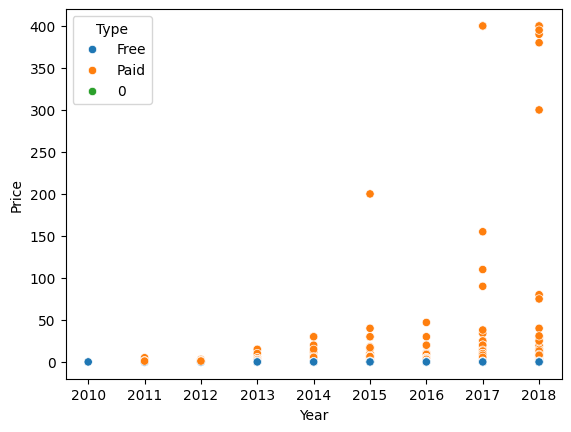

In [63]:
sns.scatterplot(x=df['Year'],y=df['Price'],hue=df['Type'])

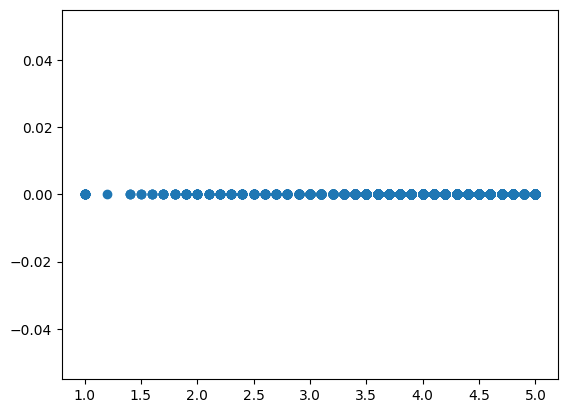

In [64]:
# using groupby, and get groups. To get free and paid type seperately.
tf=df.groupby('Type').get_group('Free')
plt.scatter(tf['Rating'],tf['Price'])

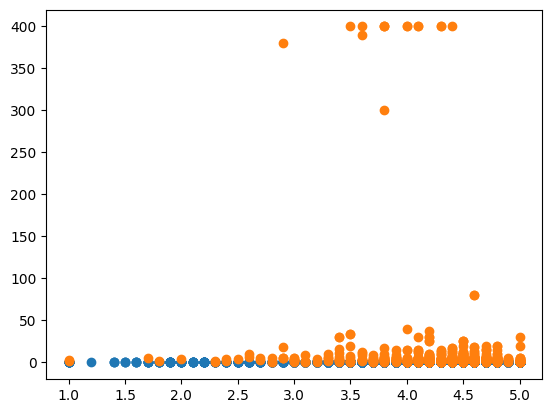

In [65]:
tf=df.groupby('Type').get_group('Free')
tp=df.groupby('Type').get_group('Paid')

plt.scatter(tf['Rating'],tf['Price'])
plt.scatter(tp['Rating'],tp['Price'])

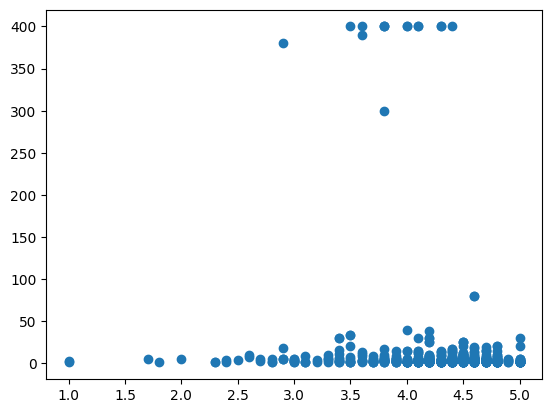

In [66]:
tp=df.groupby('Type').get_group('Paid')
plt.scatter(tp['Rating'],tp['Price'])

In [67]:
#using filter
t_f=df[df['Type']=='Free']
t_p=df[df['Type']!='Free']

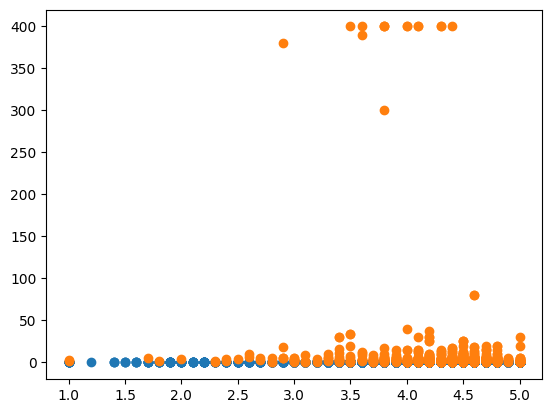

In [68]:
plt.scatter(t_f['Rating'],t_f['Price'])
plt.scatter(t_p['Rating'],t_p['Price'])

In [69]:
# to get correlation
df[['Rating','Price']].corr()
#Here 0.02 means 2%, which will be near to 0. 
#So here there is no relation between between rating and price.

,Rating,Price
Rating,1.000000,-0.021903
Price,-0.021903,1.000000


In [70]:
df['Rating']=df['Rating'].astype(float)

In [71]:
df.drop(index=[])
df=df[df['Category']!='1.9']

In [72]:
df['Category'].nunique()

33

In [73]:
category_group=df.groupby('Category')
category_rating_avg=category_group['Rating'].mean().sort_values(ascending=False).head(10)
category_rating_avg

Category
EVENTS                 4.435556
EDUCATION              4.389032
ART_AND_DESIGN         4.358065
BOOKS_AND_REFERENCE    4.346067
PERSONALIZATION        4.335987
PARENTING              4.300000
GAME                   4.286326
BEAUTY                 4.278571
HEALTH_AND_FITNESS     4.277104
SHOPPING               4.259664
Name: Rating, dtype: float64

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'EVENTS'),
  Text(1, 0, 'EDUCATION'),
  Text(2, 0, 'ART_AND_DESIGN'),
  Text(3, 0, 'BOOKS_AND_REFERENCE'),
  Text(4, 0, 'PERSONALIZATION'),
  Text(5, 0, 'PARENTING'),
  Text(6, 0, 'GAME'),
  Text(7, 0, 'BEAUTY'),
  Text(8, 0, 'HEALTH_AND_FITNESS'),
  Text(9, 0, 'SHOPPING')])

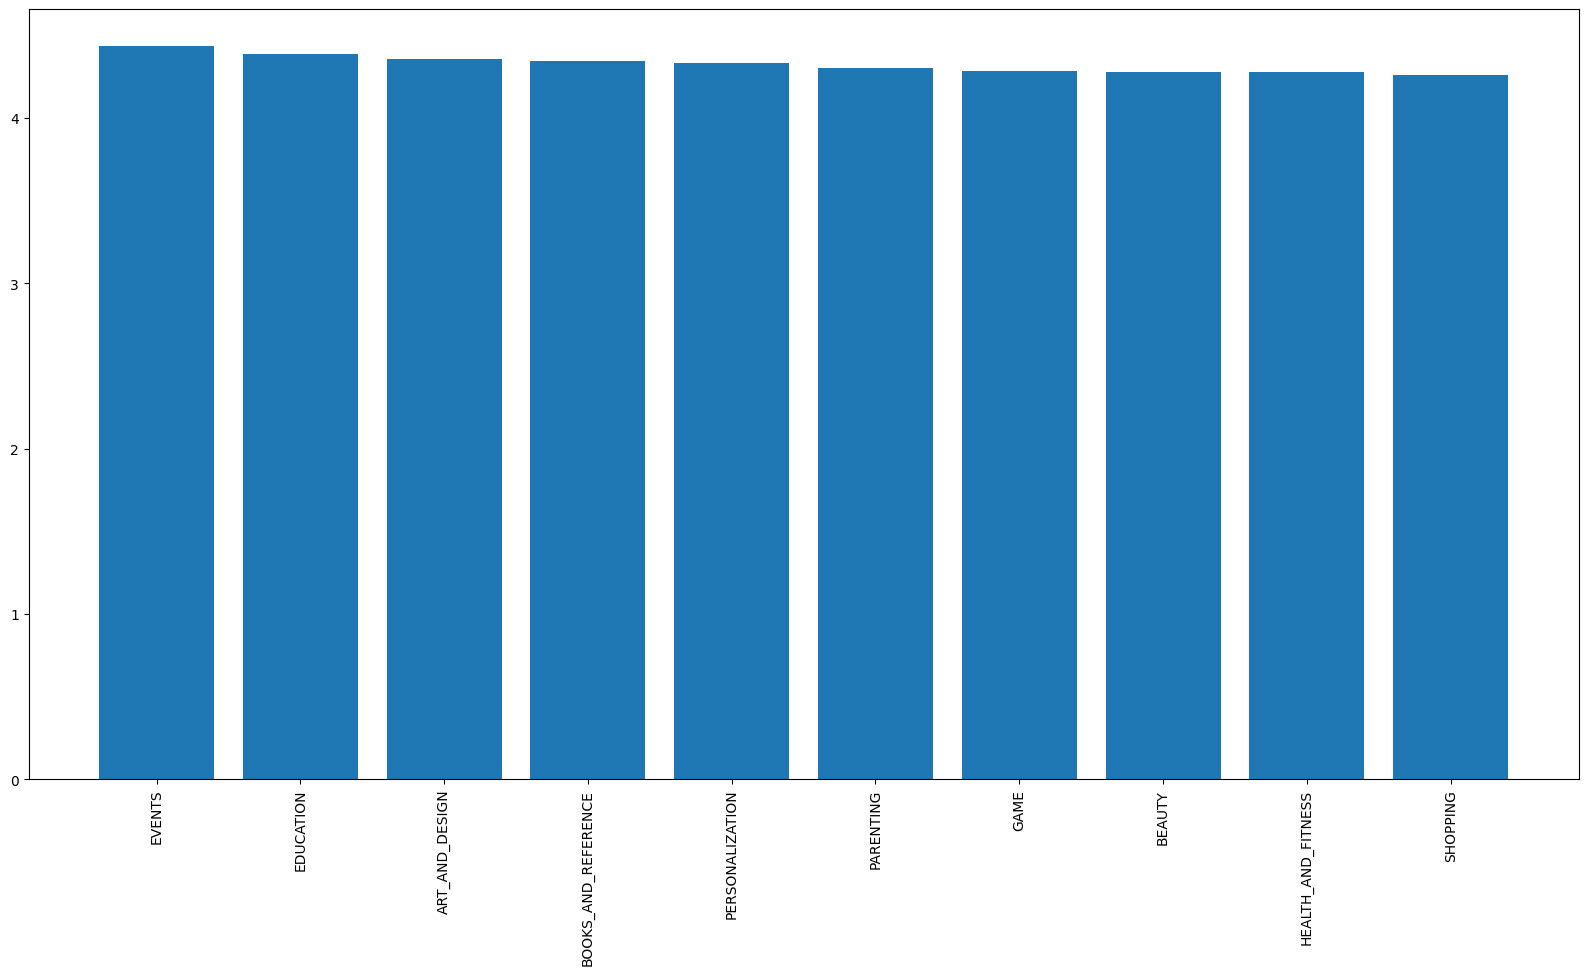

In [74]:
plt.figure(figsize=(20,10))
plt.bar(category_rating_avg.index,category_rating_avg.values) 
plt.xticks(rotation=90)


<Axes: xlabel='Category', ylabel='Rating'>

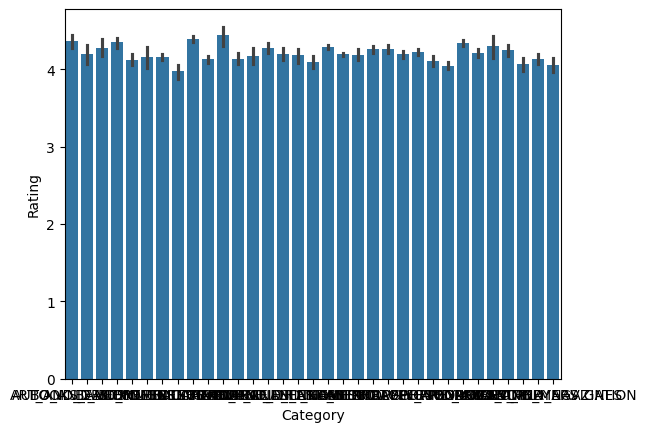

In [75]:
sns.barplot(x=df['Category'],y=df['Rating']) 
#line on the top of the bars is the mean value

<Axes: xlabel='Year', ylabel='Price'>

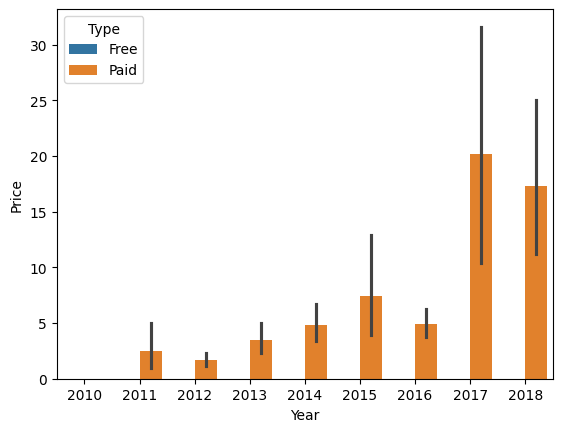

In [76]:
sns.barplot(x=df['Year'],y=df['Price'],hue=df['Type']) 

<Axes: xlabel='Year', ylabel='Rating'>

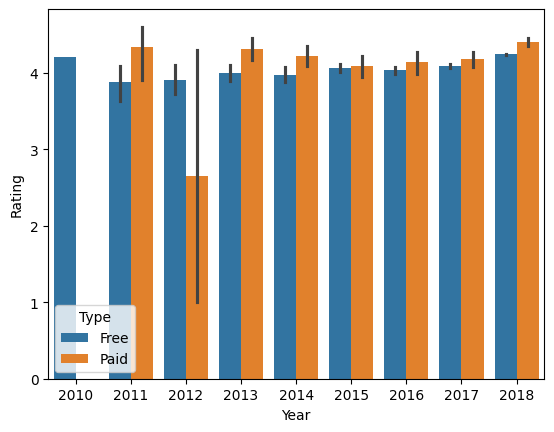

In [77]:
sns.barplot(x=df['Year'],y=df['Rating'],hue=df['Type']) 

<Axes: >

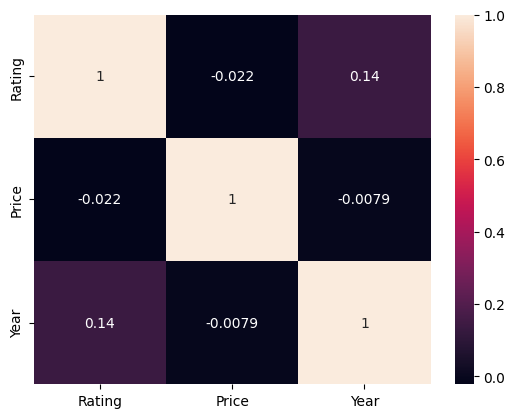

In [81]:
#heatmap

sns.heatmap(df.corr(numeric_only=True),annot=True)

#clean the data and run

In [ ]:
#subplot

fig,ax=plt.subplots(1,3,figsize=(20,10)) 
#rows=1,col=3

ax[0].plot(year)
